In [1]:
import json
import os
import random
from pathlib import Path

import kagglehub
import pandas as pd
import torch
from torch.utils.data import Subset, DataLoader

from src.dataset import TmpCifarDataset, define_transformations
from src.metrics import calculate_confusion_matrix, calculate_per_class_accuracy, plot_confusion_matrix
from src.model import SimpleCNN

/Users/vyankov/Documents/deep-learning/cnn-cifar10-from-scratch/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [3]:
experiment_dir = Path("../experiments/60")

with open(experiment_dir / "config.json", encoding="utf-8") as file:
    config_json = json.load(file)

    seed = int(config_json["seed"])

    batch_size = int(config_json["data"]["batch_size"])
    augmentation = config_json["data"]["augmentation"]

    model = config_json["model"]["name"]
    dropout = config_json["model"]["dropout"]

    learning_rate = float(config_json["training"]["learning_rate"])
    weight_decay = float(config_json["training"]["weight_decay"])
    scheduler_config = config_json["training"]["scheduler"]
    epochs = int(config_json["training"]["epochs"])

In [4]:
with open("../configs/data_stats.json", encoding="utf-8") as file:
    stats = json.load(file)
    mean = stats["mean"]
    std = stats["std"]

In [5]:
with open("../configs/data_split.json", encoding="utf-8") as file:
    split = json.load(file)

In [6]:
random.seed(seed)
torch.manual_seed(seed)

In [7]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [8]:
cifar_pd = pd.read_csv("../data/processed/cifar10_metadata.csv")

In [9]:
train_transform, val_transform = define_transformations(augmentation, mean, std)

# Reuse the exact indices used for the statistics split.
train_dataset = TmpCifarDataset(train_path, cifar_pd, transform=train_transform)
val_dataset = TmpCifarDataset(train_path, cifar_pd, transform=val_transform)
train_subset = Subset(train_dataset, split["train_indices"])
val_subset = Subset(val_dataset, split["val_indices"])

train_data_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_data_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

In [10]:
num_classes = len(train_dataset.labels.value_counts())
model = SimpleCNN(
    num_classes=num_classes,
    dropout=dropout,
).to(device)

model.load_state_dict(
    torch.load(experiment_dir / "model.pt", map_location=device)
)
model.eval()

SimpleCNN(
  (conv_block1): CNNBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block2): CNNBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [11]:
# per-class accuracy
class_names = (
    cifar_pd[["target", "label"]]
    .drop_duplicates()
    .sort_values("target")["label"]
    .tolist()
)

per_class_accuracy = calculate_per_class_accuracy(
    model,
    val_data_loader,
    class_names,
    device,
)

pd.DataFrame(
    per_class_accuracy.items(),
    columns=["Class", "Accuracy (%)"],
).sort_values("Accuracy (%)")

,Class,Accuracy (%)
7,cat,68.286445
4,bird,77.097204
8,dog,78.238342
2,deer,82.225434
9,airplane,85.481682
5,horse,87.290503
1,truck,89.167768
0,frog,90.243902
6,ship,90.896552
3,automobile,93.181818


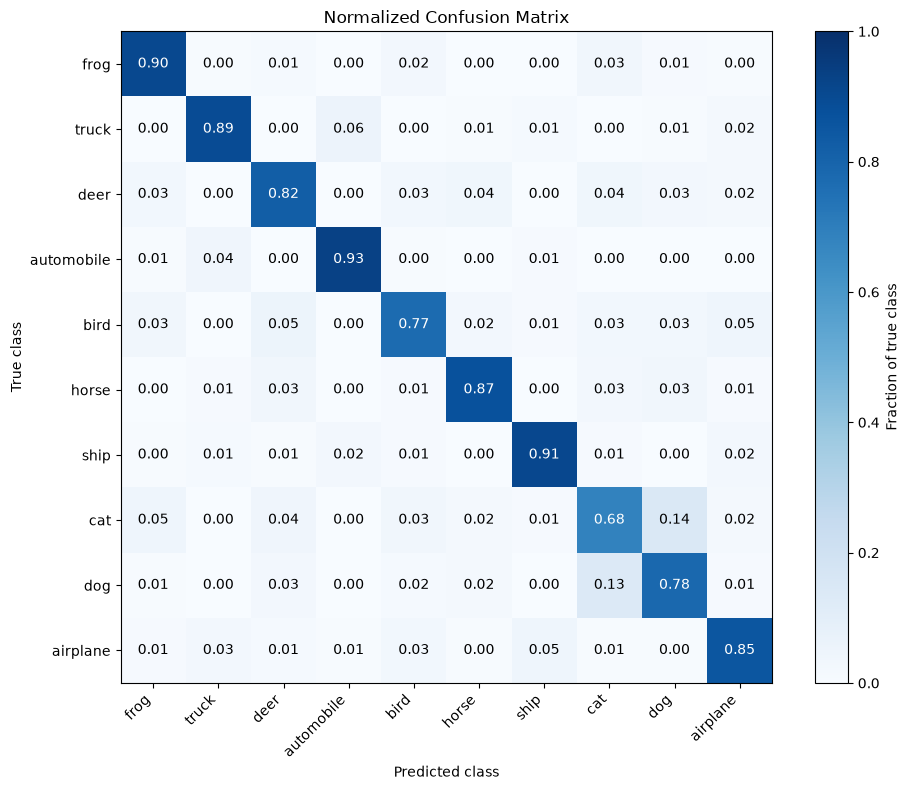

,frog,truck,deer,automobile,bird,horse,ship,cat,dog,airplane
frog,740,4,12,0,20,1,2,28,9,4
truck,2,675,0,42,2,4,10,2,5,15
deer,21,1,569,0,21,25,1,25,18,11
automobile,4,32,0,697,3,1,7,2,0,2
bird,25,1,39,2,579,18,8,22,22,35
horse,2,7,24,0,8,625,0,19,24,7
ship,3,10,5,17,7,1,659,6,0,17
cat,36,0,31,1,27,17,8,534,113,15
dog,6,2,21,1,12,14,2,103,604,7
airplane,7,19,9,5,22,3,34,5,3,630


In [12]:
confusion_matrix = calculate_confusion_matrix(
    model,
    val_data_loader,
    num_classes,
    device,
)

plot_confusion_matrix(confusion_matrix, class_names)

pd.DataFrame(
    confusion_matrix.numpy(),
    index=class_names,
    columns=class_names,
)